<a href="https://colab.research.google.com/github/anniiexp/MAT422/blob/main/1_4_SVD_LRA_and_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAT422 - Section 1.4: SVD, Low-Rank Approximation, and PCA

## Topics:

*   Singular Value decomposition
*   Low-Rank Approximation


*   Principal Component Analysis





In [39]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# 1.4.1 Singular Value Decomposition

Singular Value Decomposition is a way to rewrite any matrix A as three simpler matrices: $A = U\Sigma V^T$. There are three trasnformations:


*   $V^T$ rotates the input
*   $\Sigma$ stretches each resulting direction


*   $U$ rotates the result into the output space

Below is an example of matrix A demonstrating this.





In [40]:
# original 4x3 matrix
A = np.array([
    [3, 2, -2],
    [2, 3, -2],
    [1, 1, 0],
    [0, 2 , 1]
], dtype=float)

# compute the reduced SVD
U, s, Vt = np.linalg.svd(A, full_matrices=False)

# numpy puts singular values as a 1D array
Sigma = np.diag(s)

# reconstruct A
A_reconstructed = U @ Sigma @ Vt

print("A:")
print(A)

print("\nU:")
print(U)

print("\nSingular values:")
print(s)

print("\nSigma:")
print(Sigma)

print("\nV^T:")
print(Vt)

print("\nShapes:")
print("A:", A.shape)
print("U:", U.shape)
print("Sigma:", Sigma.shape)
print("Vt:", Vt.shape)

print("\nReconstructed A:")
print(A_reconstructed)

print("\nReconstruction is accurate:")
print(np.allclose(A, A_reconstructed))

print("\nU.T @ U:")
print(U.T @ U)

print("\nVt @ Vt.T:")
print(Vt @ Vt.T)

A:
[[ 3.  2. -2.]
 [ 2.  3. -2.]
 [ 1.  1.  0.]
 [ 0.  2.  1.]]

U:
[[-0.6781  0.3557 -0.472 ]
 [-0.6868 -0.0971  0.6709]
 [-0.2144 -0.1757 -0.5521]
 [-0.1499 -0.9128 -0.1491]]

Singular values:
[5.9355 2.243  0.8597]

Sigma:
[[5.9355 0.     0.    ]
 [0.     2.243  0.    ]
 [0.     0.     0.8597]]

V^T:
[[-0.6103 -0.6623  0.4347]
 [ 0.3109 -0.7049 -0.6375]
 [-0.7286  0.254  -0.6361]]

Shapes:
A: (4, 3)
U: (4, 3)
Sigma: (3, 3)
Vt: (3, 3)

Reconstructed A:
[[ 3.  2. -2.]
 [ 2.  3. -2.]
 [ 1.  1.  0.]
 [-0.  2.  1.]]

Reconstruction is accurate:
True

U.T @ U:
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]

Vt @ Vt.T:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]


The columns of $U$ are the left singular vectors. They describe important directions in the output space. The rows of $V^T$, or equivalently the columns of $V$, are the right singular vectors. They describe important directions in the input space.

The values along the diagonal of $\Sigma$ are the **singular values**:

$$
\Sigma =
\begin{bmatrix}
\sigma_1 & 0 & 0 \\
0 & \sigma_2 & 0 \\
0 & 0 & \sigma_3
\end{bmatrix}
$$

They are ordered from largest to smallest:

$$
\sigma_1 \geq \sigma_2 \geq \sigma_3 \geq 0
$$

A larger singular value means its corresponding direction contributes more
to the structure of $A$. A very small singular value represents a direction
that contributes little.

The products $U^TU$ and $V^TV$ are approximately identity matrices, confirming
that their singular vectors are orthonormal.
Therefore, `np.allclose(A, A_reconstructed)` returns `True`. The singular-value
plot also shows which directions contribute most strongly to $A$.

# 1.4.2 Low-Rank Matrix Approximations

A low-rank approximation creates a simpler version of a matrix by keeping its most important singular values and singular vectors. Starting with the singular value decomposition

$$
A = U\Sigma V^T,
$$

a rank-$k$ approximation is defined as

$$
A_k = U_k\Sigma_kV_k^T.
$$

Only the first $k$ singular values and their corresponding singular vectors are retained. The singular values are arranged from largest to smallest, this keeps the strongest patterns in $A$.

In [41]:
# 4x4 matrix
A = np.array([
    [9, 8, 2, 1],
    [8, 9, 1, 2],
    [2, 1, 7, 6],
    [1, 2, 6, 8]
], dtype=float)

# computing the SVD
U, s, Vt = np.linalg.svd(A, full_matrices=False)

def rank_k_approximation(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

errors = []
approximations = {}

for k in range(1, len(s) + 1):
  A_k = rank_k_approximation(U, s, Vt, k)
  approximations[k] = A_k

  error = np.linalg.norm(A - A_k, ord="fro")
  errors.append(error)

  print(f"Rank-{k} approximation:")
  print(np.round(A_k, 2))
  print("Matrix rank:", np.linalg.matrix_rank(A_k))
  print("Error:", round(error, 6))
  print()

Rank-1 approximation:
[[7.02 7.03 3.93 4.16]
 [7.03 7.05 3.93 4.17]
 [3.93 3.93 2.2  2.33]
 [4.16 4.17 2.33 2.47]]
Matrix rank: 1
Error: 12.012895

Rank-2 approximation:
[[8.51 8.5  1.48 1.47]
 [8.5  8.49 1.53 1.52]
 [1.48 1.53 6.19 6.74]
 [1.47 1.52 6.74 7.33]]
Matrix rank: 2
Error: 2.276091

Rank-3 approximation:
[[8.93 8.07 2.05 0.95]
 [8.07 8.94 0.95 2.05]
 [2.05 0.95 6.96 6.04]
 [0.95 2.05 6.04 7.96]]
Matrix rank: 3
Error: 0.211755

Rank-4 approximation:
[[9. 8. 2. 1.]
 [8. 9. 1. 2.]
 [2. 1. 7. 6.]
 [1. 2. 6. 8.]]
Matrix rank: 4
Error: 0.0



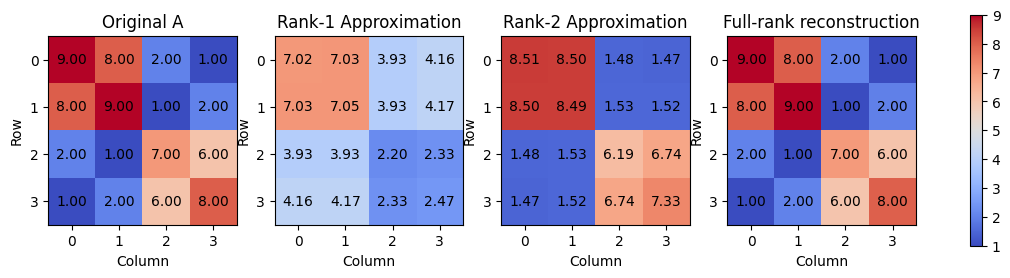

In [42]:
# comparing the matrices visually
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

matrices = [
    A,
    approximations[1],
    approximations[2],
    approximations[4]
]

titles = [
    "Original A",
    "Rank-1 Approximation",
    "Rank-2 Approximation",
    "Full-rank reconstruction"
]

vmin = A.min()
vmax = A.max()

for ax, matrix, title in zip(axes, matrices, titles):
  image = ax.imshow(
      matrix,
      cmap="coolwarm",
      vmin=vmin,
      vmax=vmax
  )

  ax.set_title(title)
  ax.set_xlabel("Column")
  ax.set_ylabel("Row")

  # display each matrix value
  for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
      ax.text(
          j,
          i,
          f"{matrix[i, j]:.2f}",
          ha="center",
          va="center",
          color="black"
      )

plt.colorbar(image, ax=axes, shrink=0.75)
plt.show()

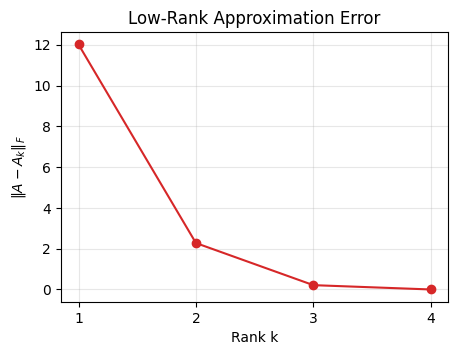

In [43]:
# plotting approximation error
k_values = np.arange(1, len(errors) + 1)

plt.figure(figsize=(5, 3.5))
plt.plot(k_values, errors, marker="o", color="tab:red")

plt.xticks(k_values)
plt.xlabel("Rank k")
plt.ylabel(r"$\|A-A_k\|_F$")
plt.title("Low-Rank Approximation Error")
plt.grid(True, alpha=0.3)
plt.show()

This matrix has 2 visible groups of large values. The rank-1 approxmiation shows the strongest overall pattern.
The rank-2 approximation retains another singular value, so the frobenius error is smaller.
As $k$ increases, more singular values and singular vectors are retained. The approximation becomes similar to the original matrix. When all four singular are used, the original matrix is reconstructed up to floating-point rounding error.

# 1.4.3 Principal Component Analysis

Principal Component Analysis finds the directions in which a dataset varies the most. Before PCA is performed, the mean of each feature is subtracted to center the data around zero.

PCA then uses SVD to find the component directions. PC1 captures the largest amount of variation in the data and PC2 captures the next largest amount of variation and is perpendicular to PC1.

The data can then be projected to these new directions to show how much each data point contributes to PC1 and PC2.

In [44]:
# dataset with two similar features
X = np.array([
    [1.0, 1.1],
    [2.0, 1.9],
    [3.0, 3.2],
    [4.0, 3.8],
    [5.0, 5.1],
    [6.0, 5.9]
])

# center the data
mean = X.mean(axis=0)
X_centered = X - mean

# apply SVD
U, s, Vt = np.linalg.svd(X_centered, full_matrices=False)

# the data onto PC1 and PC2
scores = X_centered @ Vt.T

explained_ratio = s**2 / np.sum(s**2)

print("Feature means:")
print(mean)

print("\nRows of Vt:")
print(Vt)

print("\nVariance ratios:")
print(explained_ratio)

print("\nProjected data:")
print(scores)

Feature means:
[3.5 3.5]

Rows of Vt:
[[ 0.7141  0.7   ]
 [-0.7     0.7141]]

Variance ratios:
[0.9984 0.0016]

Projected data:
[[-3.4654  0.0363]
 [-2.1912 -0.0925]
 [-0.5671  0.1358]
 [ 0.5671 -0.1358]
 [ 2.1912  0.0925]
 [ 3.4654 -0.0363]]


The first row of $Vt$ is PC1, and the second row is PC2. The 2 columns of scores give every points coordinates along PC1 and PC2.

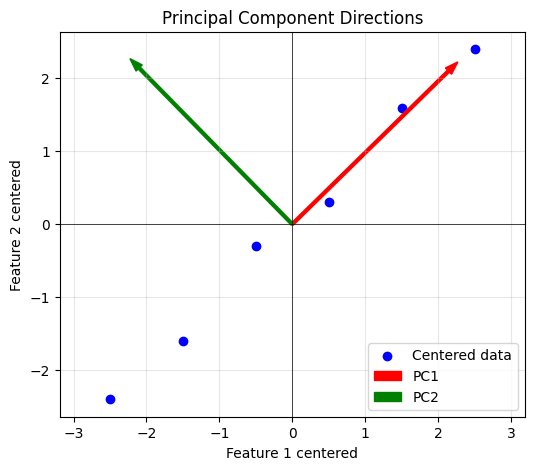

In [45]:
pc1 = Vt[0]
pc2 = Vt[1]
arrow_length = 3

plt.figure(figsize=(6, 5))

# plot centered data
plt.scatter(
    X_centered[:, 0],
    X_centered[:, 1],
    color="blue",
    label="Centered data"
)

# plot PC1
plt.arrow(
    0, 0,
    pc1[0] * arrow_length,
    pc1[1] * arrow_length,
    color="red",
    width=0.04,
    label="PC1"
)

# plot PC2
plt.arrow(
    0, 0,
    pc2[0] * arrow_length,
    pc2[1] * arrow_length,
    color="green",
    width=0.04,
    label="PC2"
)

plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("Feature 1 centered")
plt.ylabel("Feature 2 centered")
plt.title("Principal Component Directions")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.show()

The 2 original features are strongly related because they increase together. Therefore, most of the data's variation follows on diagonal direction.

PC1 points along the main direction and has the largest explained variance. PC2 is perpendicular to PC1 and captures the smaller variance.

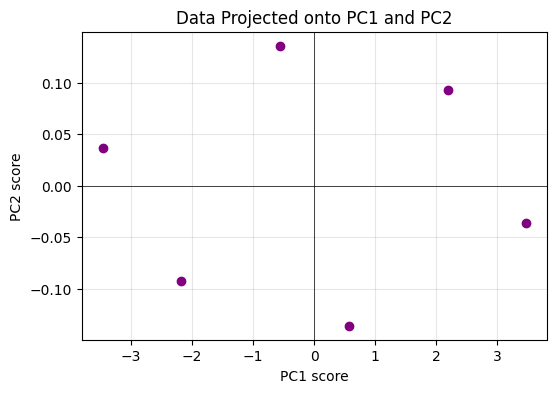

In [46]:
plt.figure(figsize=(6, 4))

plt.scatter(scores[:, 0], scores[:, 1], color="purple")

plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("Data Projected onto PC1 and PC2")
plt.grid(True, alpha=0.3)
plt.show()

After projection, the data is mostly spread along the PC1 axis. This explains that PC1 has most of the useful information.

# Reflection



*   Singular value decomposition: factored a matrix as $A = U\Sigma V^T$, verified that singular vectors are orthonormal and checked that multiplying 3 matrices reconstructs the original matrix.
*   Low-rank matrix approximation: used the largest singular values to create rank-1 and rank-2 approximations, compared them to original matrix, and showed that the approximation error decreases as the rank increases.

*   Principal component analysis: created a different dataset, used SVD to find its principal directions, projected the data onto PC1 and PC2, and compared the variations.




